In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv("application_train.csv")
df.shape
print(df.isnull().sum())
print(df.head())

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1      

In [ ]:
X=df.drop(columns=['TARGET'])
y=df['TARGET']

code_gender=pd.get_dummies(X['CODE_GENDER'], drop_first=True)
contract_type=pd.get_dummies(X['NAME_CONTRACT_TYPE'], drop_first=True)


In [ ]:
X=X.drop(columns=['CODE_GENDER','NAME_CONTRACT_TYPE'],axis=1)
X=pd.concat([X,code_gender,contract_type,],axis=1)

In [ ]:
X = X.rename(columns={
    'M': 'GENDER_M',
    'XNA': 'GENDER_XNA',
    'Revolving loans': 'CONTRACT_Revolving_loans'
    })

target_cols = ['GENDER_M', 'GENDER_XNA', 'CONTRACT_Revolving_loans']
X[target_cols] = X[target_cols].astype(int)

In [ ]:
print(X.head())

   SK_ID_CURR FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  \
0      100002            N               Y             0          202500.0   
1      100003            N               N             0          270000.0   
2      100004            Y               Y             0           67500.0   
3      100006            N               Y             0          135000.0   
4      100007            N               Y             0          121500.0   

   AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE NAME_TYPE_SUITE NAME_INCOME_TYPE  \
0    406597.5      24700.5         351000.0   Unaccompanied          Working   
1   1293502.5      35698.5        1129500.0          Family    State servant   
2    135000.0       6750.0         135000.0   Unaccompanied          Working   
3    312682.5      29686.5         297000.0   Unaccompanied          Working   
4    513000.0      21865.5         513000.0   Unaccompanied          Working   

   ... FLAG_DOCUMENT_21 AMT_REQ_CREDIT_BUREAU_HOUR

In [ ]:
print(df.isnull().sum())

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64


these above 41519 people are THIN FILE

In [ ]:
print(df['TARGET'].value_counts())
print("\nPercentage breakdown:")
print(df['TARGET'].value_counts(normalize=True) * 100)

TARGET
0    282686
1     24825
Name: count, dtype: int64

Percentage breakdown:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


data is highly imbalanced so we will use SMOTE

In [ ]:
# Convert days to positive years to make it human-readable
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365

# Check the average age for each target group
print(df.groupby('TARGET')['AGE_YEARS'].mean())

TARGET
0    44.214182
1    40.780351
Name: AGE_YEARS, dtype: float64


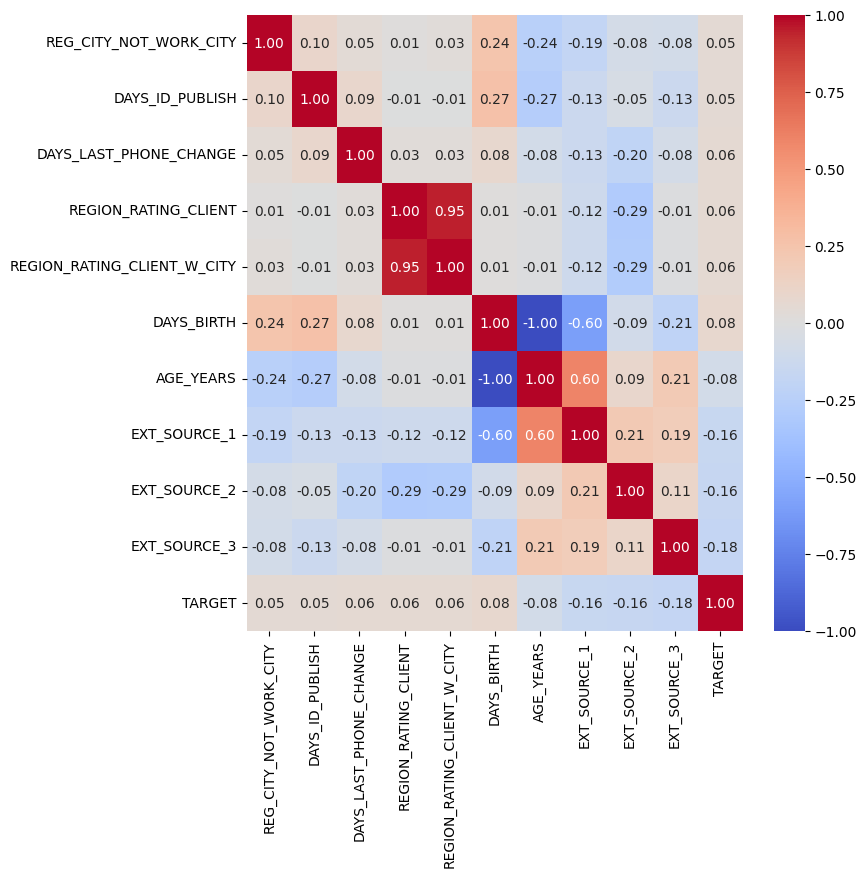

In [ ]:
# 1. Get the 10 columns that correlate most with TARGET
numeric_df = df.select_dtypes(include=['number'])
top_features = numeric_df.corr()['TARGET'].abs().sort_values().tail(11).index

# 2. Compute correlation matrix for just those columns
clean_matrix = df[top_features].corr()

# 3. Plot the clean heatmap
plt.figure(figsize=(8, 8))
sns.heatmap(clean_matrix, cmap='coolwarm', annot=True, fmt=".2f")
plt.show()


Why is Multicollinearity bad?
When two features are this tightly coupled, it confuses linear models and can even distort feature importance calculations in tree-based models like XGBoost. The models don't know which feature should get the credit for predicting the target, making your model's explanation metrics (like SHAP values) unstable and hard to trust.

In [ ]:
df.drop(columns=['REGION_RATING_CLIENT'])

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.180822
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,52.068493
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,54.608219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,25.553425
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,56.917808
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0,41.002740
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,32.769863


The Discovery: Found a strong 0.62 correlation between DAYS_BIRTH (Age) and FLAG_EMP_PHONE (Work Phone Flag). While this mostly captures retirees (older people who naturally lack a workplace landline), it creates a dangerous blind spot for self-employed business owners and entrepreneurs who use personal mobile numbers for work.

The Risk: A machine learning model might misclassify these high-earning business owners as "unemployed/retired" and unfairly penalize them or reject their loan applications.

The Solution: Created a smart composite feature (IS_ENTREPRENEUR_HIDDEN) that explicitly flags applicants who have no work phone, belong to a commercial/business income type, but possess a high total income.

Impact: This prevents feature redundancy, captures a critical non-linear relationship (feature interaction) before modeling, and protects eligible, unbanked business owners from automated rejection.

In [ ]:
print(df.groupby('NAME_INCOME_TYPE')['FLAG_EMP_PHONE'].mean())

median_income=df['AMT_INCOME_TOTAL'].median()
# Broadening the logic to capture self-employed individuals without a work phone
df['IS_ENTREPRENEUR_HIDDEN'] = (
    (df['FLAG_EMP_PHONE'] == 0) &
    (df['ORGANIZATION_TYPE'] == 'Self-employed') &
    (df['AMT_INCOME_TOTAL'] > median_income)
).astype(int)

print(df['IS_ENTREPRENEUR_HIDDEN'].value_counts())


NAME_INCOME_TYPE
Businessman             0.900000
Commercial associate    0.999944
Maternity leave         1.000000
Pensioner               0.000181
State servant           1.000000
Student                 1.000000
Unemployed              0.000000
Working                 0.999956
Name: FLAG_EMP_PHONE, dtype: float64
IS_ENTREPRENEUR_HIDDEN
0    307509
1         2
Name: count, dtype: int64


In [1]:
import pandas as pd

bureau = pd.read_csv('data/raw/bureau.csv')
installments = pd.read_csv('data/raw/installments_payments.csv')

print("BUREAU SHAPE:", bureau.shape)
print(bureau.dtypes)
print("---")
print("INSTALLMENTS SHAPE:", installments.shape)
print(installments.dtypes)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/bureau.csv'